# IT3091 - Member 2 - IT24100533 - Danthanarayana D.M.R



In [1]:
from pathlib import Path

REPO_PATH = Path("/content/IT3091---Machine-Learning-Assignment")

if not REPO_PATH.exists():
    !git clone https://github.com/DTD-Wijesinghe/IT3091---Machine-Learning-Assignment.git

%cd /content/IT3091---Machine-Learning-Assignment

Cloning into 'IT3091---Machine-Learning-Assignment'...
remote: Enumerating objects: 140, done.
remote: Counting objects: 100% (140/140), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 140 (delta 49), reused 41 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (140/140), 8.09 MiB | 4.67 MiB/s, done.
Resolving deltas: 100% (49/49), done.
/content/IT3091---Machine-Learning-Assignment


## Member 2 - Weather and location data

In [2]:
!pip -q install openpyxl joblib

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

REPO_PATH = Path("/content/IT3091---Machine-Learning-Assignment")
RAW_PATH = REPO_PATH / "Raw Datasets"
PREPROCESSED_PATH = REPO_PATH / "Preprocessed Datasets"

PREPROCESSED_PATH.mkdir(parents=True, exist_ok=True)

print("Raw data:", RAW_PATH)
print("Preprocessed data:", PREPROCESSED_PATH)

Raw data: /content/IT3091---Machine-Learning-Assignment/Raw Datasets
Preprocessed data: /content/IT3091---Machine-Learning-Assignment/Preprocessed Datasets


In [3]:
WEATHER_FILE = RAW_PATH / "weatherData.csv"
LOCATION_FILE = RAW_PATH / "locationData.csv"

if not WEATHER_FILE.exists():
    matches = list(RAW_PATH.glob("*weatherData*.csv"))
    if matches:
        WEATHER_FILE = matches[0]

if not LOCATION_FILE.exists():
    matches = list(RAW_PATH.glob("*locationData*.csv"))
    if matches:
        LOCATION_FILE = matches[0]

if not WEATHER_FILE.exists() or not LOCATION_FILE.exists():
    raise FileNotFoundError(
        "weatherData.csv or locationData.csv was not found in Raw Datasets."
    )

print("Weather file:", WEATHER_FILE.name)
print("Location file:", LOCATION_FILE.name)

Weather file: weatherData.csv
Location file: locationData.csv


In [4]:
weather = pd.read_csv(WEATHER_FILE)
locations = pd.read_csv(LOCATION_FILE)

weather = weather.loc[
    :,
    ~weather.columns.astype(str).str.lower().isin(["index", "unnamed: 0"])
]

locations = locations.loc[
    :,
    ~locations.columns.astype(str).str.lower().isin(["index", "unnamed: 0"])
]

location_cols = [
    c for c in [
        "location_id",
        "city_name",
        "latitude",
        "longitude",
        "elevation"
    ]
    if c in locations.columns
]

weather = weather.merge(
    locations[location_cols],
    on="location_id",
    how="left",
    validate="many_to_one"
)

if "city_name" in weather.columns and weather["city_name"].isna().any():
    raise ValueError("Some location_id values did not match locationData.csv.")

weather["date"] = pd.to_datetime(weather["date"], errors="coerce")
weather = weather.dropna(subset=["date"]).copy()

print("Weather shape:", weather.shape)
print("Weather date range:", weather["date"].min(), "to", weather["date"].max())
print("Locations:", weather["location_id"].nunique())

if "city_name" in weather.columns:
    print("Places:", weather["city_name"].nunique())
    display(
        weather[["location_id", "city_name"]]
        .drop_duplicates()
        .sort_values("city_name")
        .head(20)
    )

display(weather.head())

Weather shape: (142371, 25)
Weather date range: 2010-01-01 00:00:00 to 2024-06-08 00:00:00
Locations: 27
Places: 27


,location_id,city_name
79095,15,Ampara
100187,19,Anuradhapura
110733,21,Badulla
137098,26,Bandarawela
73822,14,Batticaloa
0,0,Colombo
31638,6,Galle
5273,1,Gampaha
42184,8,Hambantota
47457,9,Jaffna


,location_id,date,weather_code (wmo code),temperature_2m_max (°C),temperature_2m_min (°C),temperature_2m_mean (°C),apparent_temperature_max (°C),apparent_temperature_min (°C),apparent_temperature_mean (°C),daylight_duration (s),sunshine_duration (s),precipitation_sum (mm),rain_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm),sunrise,sunset,city_name,latitude,longitude,elevation
0,0,2010-01-01,1,30.1,22.6,26.0,34.5,25.0,29.0,42220.20,38905.73,0.0,0.0,0,12.2,27.4,19,20.92,4.61,06:22,18:05,Colombo,6.924429,79.90725,4
1,0,2010-01-02,51,30.1,23.7,26.3,33.9,26.1,29.7,42225.71,37451.01,0.1,0.1,1,13.0,27.0,24,17.71,3.91,06:22,18:06,Colombo,6.924429,79.90725,4
2,0,2010-01-03,51,29.6,23.1,26.0,34.5,26.2,29.9,42231.68,33176.43,0.6,0.6,3,12.3,27.4,17,17.76,3.66,06:22,18:06,Colombo,6.924429,79.90725,4
3,0,2010-01-04,2,28.9,23.1,25.7,31.7,26.1,28.4,42238.11,38289.20,0.0,0.0,0,17.0,34.6,357,16.50,3.75,06:23,18:07,Colombo,6.924429,79.90725,4
4,0,2010-01-05,1,28.1,21.3,24.6,30.0,22.9,26.2,42244.99,39113.82,0.0,0.0,0,18.7,37.1,353,23.61,5.00,06:23,18:07,Colombo,6.924429,79.90725,4


In [6]:
def season_and_year(dt):
    m, y = dt.month, dt.year

    if m in [4, 5, 6, 7, 8]:
        return pd.Series(["Yala", y])

    if m in [9, 10, 11, 12]:
        return pd.Series(["Maha", y])

    if m in [1, 2, 3]:
        return pd.Series(["Maha", y - 1])

    return pd.Series([pd.NA, pd.NA])


weather[["Season", "SeasonYear"]] = weather["date"].apply(season_and_year)
weather["SeasonYear"] = pd.to_numeric(
    weather["SeasonYear"],
    errors="coerce"
).astype("Int64")

season_coverage = (
    weather[
        weather["SeasonYear"].between(2012, 2023)
    ]
    .groupby(["SeasonYear", "Season"], as_index=False)
    .agg(
        FirstDate=("date", "min"),
        LastDate=("date", "max"),
        WeatherDays=("date", "nunique"),
        Locations=("location_id", "nunique")
    )
)

print("Season coverage check:")
display(season_coverage.tail(10))

Season coverage check:


,SeasonYear,Season,FirstDate,LastDate,WeatherDays,Locations
14,2019,Maha,2019-09-01,2020-03-31,213,27
15,2019,Yala,2019-04-01,2019-08-31,153,27
16,2020,Maha,2020-09-01,2021-03-31,212,27
17,2020,Yala,2020-04-01,2020-08-31,153,27
18,2021,Maha,2021-09-01,2022-03-31,212,27
19,2021,Yala,2021-04-01,2021-08-31,153,27
20,2022,Maha,2022-09-01,2023-03-31,212,27
21,2022,Yala,2022-04-01,2022-08-31,153,27
22,2023,Maha,2023-09-01,2024-03-31,213,27
23,2023,Yala,2023-04-01,2023-08-31,153,27


In [7]:
WEATHER_COLS = [
    "temperature_2m_mean (°C)",
    "precipitation_sum (mm)",
    "wind_speed_10m_max (km/h)",
    "shortwave_radiation_sum (MJ/m²)",
    "et0_fao_evapotranspiration (mm)"
]

missing_weather_cols = [
    c for c in WEATHER_COLS
    if c not in weather.columns
]

if missing_weather_cols:
    raise KeyError(
        f"Missing required weather columns: {missing_weather_cols}"
    )

for c in WEATHER_COLS:
    weather[c] = pd.to_numeric(
        weather[c],
        errors="coerce"
    )

weather_daily_nat = (
    weather
    .groupby("date", as_index=False)[WEATHER_COLS]
    .mean()
)

print("National daily weather rows:", len(weather_daily_nat))
display(weather_daily_nat.head())

National daily weather rows: 5273


,date,temperature_2m_mean (°C),precipitation_sum (mm),wind_speed_10m_max (km/h),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm)
0,2010-01-01,24.462963,0.037037,17.003704,18.285556,4.022593
1,2010-01-02,24.588889,0.396296,16.344444,16.782963,3.646667
2,2010-01-03,24.111111,1.181481,14.755556,15.467037,3.206296
3,2010-01-04,23.962963,0.666667,13.662963,16.379630,3.525185
4,2010-01-05,23.455556,0.033333,14.425926,21.736667,4.498148


## Leakage-safe 3-month weather features

In [8]:
forecast_rows = []

for year in range(2012, 2024):
    forecast_rows.append({
        "Year": year,
        "Season": "Yala",
        "ForecastDate": pd.Timestamp(
            year=year,
            month=4,
            day=1
        )
    })

    forecast_rows.append({
        "Year": year,
        "Season": "Maha",
        "ForecastDate": pd.Timestamp(
            year=year,
            month=9,
            day=1
        )
    })

forecast_dates = pd.DataFrame(forecast_rows)

display(forecast_dates.head())

,Year,Season,ForecastDate
0,2012,Yala,2012-04-01
1,2012,Maha,2012-09-01
2,2013,Yala,2013-04-01
3,2013,Maha,2013-09-01
4,2014,Yala,2014-04-01


In [9]:
weather_features = []

for _, row in forecast_dates.iterrows():
    forecast_date = row["ForecastDate"]
    start_date = forecast_date - pd.DateOffset(months=3)

    window = weather_daily_nat[
        (weather_daily_nat["date"] >= start_date) &
        (weather_daily_nat["date"] < forecast_date)
    ].copy()

    weather_features.append({
        "Year": int(row["Year"]),
        "Season": row["Season"],
        "ForecastDate": forecast_date,
        "WeatherWindowStart": start_date,
        "WeatherWindowEnd": forecast_date - pd.Timedelta(days=1),
        "Rainfall_3M_mm":
            window["precipitation_sum (mm)"].sum(min_count=1),
        "TempMean_3M_C":
            window["temperature_2m_mean (°C)"].mean(),
        "WindSpeed_3M_kmh":
            window["wind_speed_10m_max (km/h)"].mean(),
        "SolarRadiation_3M_MJ_m2":
            window["shortwave_radiation_sum (MJ/m²)"].mean(),
        "ET0_3M_mm":
            window["et0_fao_evapotranspiration (mm)"].sum(min_count=1),
        "WeatherDays_3M":
            window["date"].nunique()
    })

weather_3m = pd.DataFrame(weather_features)

weather_3m["Leakage_Check"] = (
    weather_3m["WeatherWindowEnd"]
    < weather_3m["ForecastDate"]
)

weather_3m["Weather_Completeness_OK"] = (
    weather_3m["WeatherDays_3M"] >= 75
)

if not weather_3m["Leakage_Check"].all():
    raise ValueError("Future weather leakage was detected.")

if not weather_3m["Weather_Completeness_OK"].all():
    bad = weather_3m.loc[
        ~weather_3m["Weather_Completeness_OK"],
        ["Year", "Season", "WeatherDays_3M"]
    ]
    raise ValueError(
        "Incomplete 3-month weather windows found:\n"
        + bad.to_string(index=False)
    )

print("Leakage check:")
print(weather_3m["Leakage_Check"].value_counts())

print("\nWeather completeness:")
print(weather_3m["Weather_Completeness_OK"].value_counts())

display(weather_3m.tail(10))

Leakage check:
Leakage_Check
True    24
Name: count, dtype: int64

Weather completeness:
Weather_Completeness_OK
True    24
Name: count, dtype: int64


,Year,Season,ForecastDate,WeatherWindowStart,WeatherWindowEnd,Rainfall_3M_mm,TempMean_3M_C,WindSpeed_3M_kmh,SolarRadiation_3M_MJ_m2,ET0_3M_mm,WeatherDays_3M,Leakage_Check,Weather_Completeness_OK
14,2019,Yala,2019-04-01,2019-01-01,2019-03-31,233.359259,25.212140,15.569342,20.749947,397.587037,90,True,True
15,2019,Maha,2019-09-01,2019-06-01,2019-08-31,411.955556,26.996940,21.273551,18.770890,414.279630,92,True,True
16,2020,Yala,2020-04-01,2020-01-01,2020-03-31,105.403704,25.679528,16.798128,21.646777,429.848148,91,True,True
17,2020,Maha,2020-09-01,2020-06-01,2020-08-31,375.785185,26.671618,19.207287,18.855789,395.234444,92,True,True
18,2021,Yala,2021-04-01,2021-01-01,2021-03-31,465.262963,24.744774,14.810617,18.874930,351.975926,90,True,True
19,2021,Maha,2021-09-01,2021-06-01,2021-08-31,439.225926,26.359461,20.130676,19.065225,397.385185,92,True,True
20,2022,Yala,2022-04-01,2022-01-01,2022-03-31,218.688889,24.939918,15.038601,20.776477,389.066667,90,True,True
21,2022,Maha,2022-09-01,2022-06-01,2022-08-31,441.544444,26.047866,19.900242,19.104799,393.297407,92,True,True
22,2023,Yala,2023-04-01,2023-01-01,2023-03-31,322.777778,24.415391,15.564444,20.301675,375.302593,90,True,True
23,2023,Maha,2023-09-01,2023-06-01,2023-08-31,310.977778,27.081119,20.283414,20.702174,445.984815,92,True,True


In [10]:
location_coverage = (
    locations[location_cols]
    .drop_duplicates()
    .sort_values(
        "city_name"
        if "city_name" in location_cols
        else "location_id"
    )
)

weather_output = (
    PREPROCESSED_PATH
    / "02_weather_preprocessed.csv"
)

location_output = (
    PREPROCESSED_PATH
    / "02_weather_location_coverage.csv"
)

weather_3m.to_csv(
    weather_output,
    index=False
)

location_coverage.to_csv(
    location_output,
    index=False
)

print("Saved:", weather_output)
print("Saved:", location_output)
print("Weather feature rows:", len(weather_3m))

Saved: /content/IT3091---Machine-Learning-Assignment/Preprocessed Datasets/02_weather_preprocessed.csv
Saved: /content/IT3091---Machine-Learning-Assignment/Preprocessed Datasets/02_weather_location_coverage.csv
Weather feature rows: 24


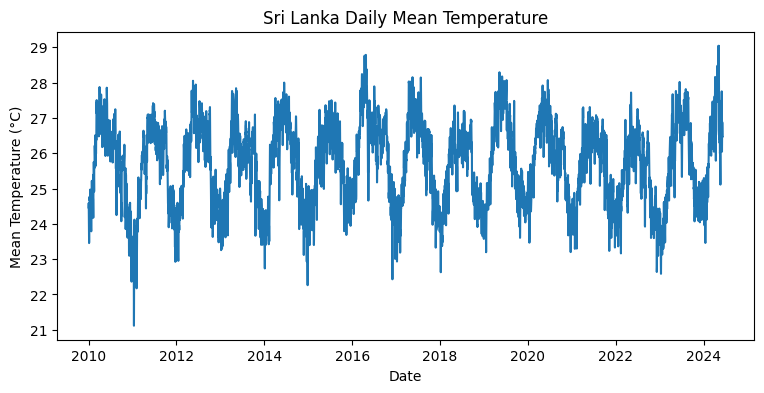

In [11]:
plt.figure(figsize=(9, 4))
plt.plot(
    weather_daily_nat["date"],
    weather_daily_nat["temperature_2m_mean (°C)"]
)
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.title("Sri Lanka Daily Mean Temperature")
plt.show()

In [ ]:
from getpass import getpass
from google.colab import _message
import subprocess

MEMBER_NAME = "Danthanarayana D.M.R"
NOTEBOOK_NAME = "02_IT24100533_Danthanarayana_DMR_Weather.ipynb"

FILES_TO_ADD = [
    "Preprocessed Datasets/02_weather_preprocessed.csv",
    "Preprocessed Datasets/02_weather_location_coverage.csv"
]

current_notebook = _message.blocking_request(
    "get_ipynb",
    request="",
    timeout_sec=10
)

notebook_path = REPO_PATH / NOTEBOOK_NAME

with open(
    notebook_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        current_notebook["ipynb"],
        f,
        ensure_ascii=False,
        indent=1
    )

print("Saved notebook:", notebook_path.name)

github_email = input("GitHub email: ").strip()
github_username = input("GitHub username: ").strip()
github_token = getpass("GitHub Personal Access Token: ")

subprocess.run(
    ["git", "config", "user.name", MEMBER_NAME],
    cwd=REPO_PATH,
    check=True
)

subprocess.run(
    ["git", "config", "user.email", github_email],
    cwd=REPO_PATH,
    check=True
)

for item in [NOTEBOOK_NAME] + FILES_TO_ADD:
    subprocess.run(
        ["git", "add", item],
        cwd=REPO_PATH,
        check=True
    )

status = subprocess.run(
    ["git", "status", "--short"],
    cwd=REPO_PATH,
    text=True,
    capture_output=True,
    check=True
)

print(status.stdout)

if status.stdout.strip():
    subprocess.run(
        [
            "git",
            "commit",
            "-m",
            "Member 2: Fix leakage-safe weather and location preprocessing"
        ],
        cwd=REPO_PATH,
        check=True
    )
else:
    print("Nothing new to commit.")

askpass = Path("/tmp/git_askpass.sh")

askpass.write_text(
    '#!/bin/sh\n'
    'case "$1" in\n'
    '  *Username*) echo "$GITHUB_USERNAME" ;;\n'
    '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
    'esac\n'
)

askpass.chmod(0o700)

env = os.environ.copy()
env["GITHUB_USERNAME"] = github_username
env["GITHUB_TOKEN"] = github_token
env["GIT_ASKPASS"] = str(askpass)

result = subprocess.run(
    ["git", "push", "origin", "main"],
    cwd=REPO_PATH,
    env=env,
    text=True,
    capture_output=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        "Push failed. Check the GitHub username, token and repository permission."
    )

print("Push completed.")